TRUE OPTIMUM:  F* = 13.000000
  x* = (5.0000, 5.0000)   F = 13.000000
  x* = (7.0000, 3.0000)   F = 13.000000


Building 2D scenario models ...
  3 scenarios, first-stage dim = 2
Building BaseBundle + MSBundle ...
Set parameter MIPGap to value 0.1
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 30
Set parameter MIPGap to value 0.1
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 30
Set parameter MIPGap to value 0.1
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 30
  Done.

Initial nodes (3):
  (0.0, 0.0)  F_true=80.0000  F_solver=80.0000
  (10.0, 0.0)  F_true=38.6667  F_solver=38.6667
  (0.0, 10.0)  F_true=53.3333  F_solver=53.3333
Initial triangles: 1

--- Running 2D simplex loop (target=30 nodes) ---
Discarded solution information
Discarded solution information
Discarded solution information
[Iter   0] nodes=3  tris=1  Tru

[Iter   1] nodes=4  tris=3  TrueUB=18.3333  TrueGap=5.3333e+00  SurLB/S=0.5524  (select=min_SurLB)
         -> split [(0.0, 10.0), (5.0, 3.0), (10.0, 0.0)]  SurLB/S=0.5524


[Iter   2] nodes=5  tris=4  TrueUB=13.0000  TrueGap=0.0000e+00  SurLB/S=6.4667  (select=min_SurLB)
  STOP: true gap converged.

--- Done in 1.75s, 5 nodes, 4 triangles ---
  True F*:       13.000000  at [(5.0, 5.0), (7.0, 3.0)]
  TrueUB (best): 13.000000
  TrueAbsGap:    0.000000e+00
  TrueRelGap:    0.000000e+00
  OK  True optimum FOUND.
  SurLB/S:       6.466667
  Final nodes:   5
  Final tris:    4


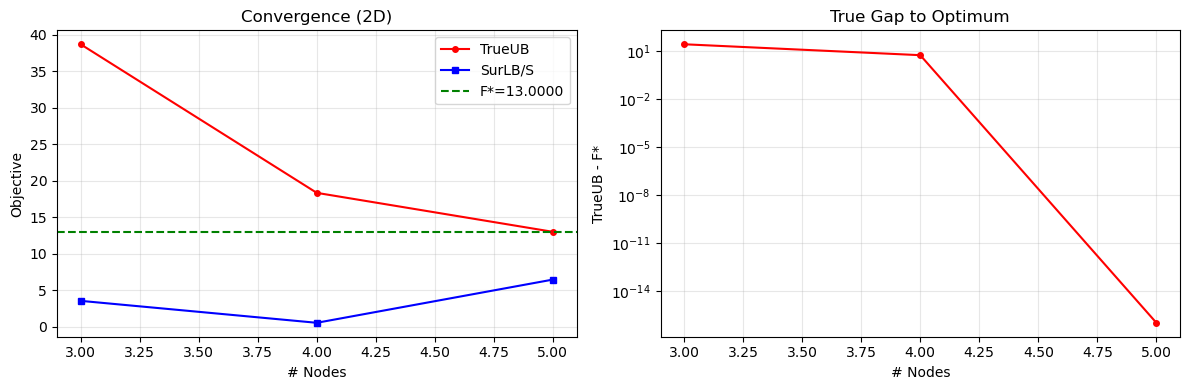

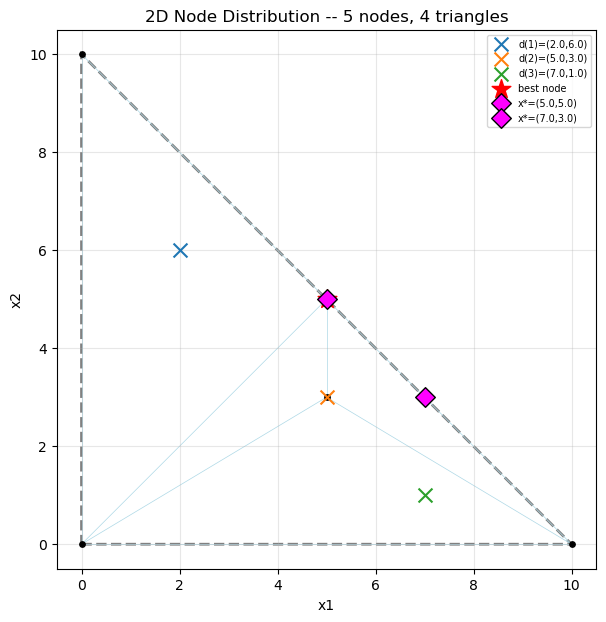

In [6]:
# run_newsvendor_2d_case.py  --  Notebook-ready 2D newsvendor simplex test
"""
2-item newsvendor with LP recourse, 2D first-stage decision (x1, x2).
Copy-paste into a Jupyter notebook cell and run.

Uses Delaunay triangulation for 2D mesh, min-SurLB selection rule,
and per-iteration 3D surface plots.
"""

# %%  ======= Setup & imports =================================================
import os, sys, csv, math
from pathlib import Path
from time import perf_counter
import numpy as np
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.spatial import Delaunay
import plotly.graph_objects as go

# Ensure the script directory is on the path so local imports work
script_dir = Path(r"C:\Users\Administrator\OneDrive\Desktop\workspace2026\219_simplex_fv\pid_simplex_fv")
os.chdir(script_dir)
if str(script_dir) not in sys.path:
    sys.path.insert(0, str(script_dir))

np.random.seed(42)

# %%  ======= Problem parameters ===============================================

B = 10.0                              # budget: x1 + x2 <= B
N_ITEMS = 2
ITEMS_SET = [1, 2]                    # 1-indexed Pyomo set

PROBS = [1/3, 1/3, 1/3]
C_SHORT = [10.0, 10.0]
C_HOLD  = [ 1.0,  1.0]

# Scenario demands: (d1, d2)
DEMANDS = [
    (2.0, 6.0),   # scenario 1
    (5.0, 3.0),   # scenario 2
    (7.0, 1.0),   # scenario 3
]
SCENARIO_NAMES = ["s1", "s2", "s3"]
S = len(DEMANDS)

# Runner parameters
TARGET_NODES = 30
GAP_STOP_TOL = 1e-4
TIME_LIMIT   = 300.0

SAVE_PLOTS = False   # set True to save PNGs (may segfault on some systems)
PLOT_DIR   = Path.cwd() / "newsvendor_2d_plots"

UB_SOLVER_OPTS = {}
LB_SOLVER_OPTS = {"TimeLimit": 30}

# %%  ======= Ground truth =====================================================

def Q_scenario_2d(x, d_s):
    """Q_s(x1,x2) = sum_i c_short_i*max(d_i-x_i,0) + c_hold_i*max(x_i-d_i,0)"""
    return sum(C_SHORT[i]*max(d_s[i]-x[i], 0.0) + C_HOLD[i]*max(x[i]-d_s[i], 0.0)
               for i in range(N_ITEMS))

def F_true_2d(x):
    """Expected recourse F(x) = (1/S) sum_s Q_s(x)."""
    return sum(Q_scenario_2d(x, d) for d in DEMANDS) / S

def compute_true_optimum_2d():
    """Enumerate candidate kink points and find global min of F over feasible region."""
    x1_cands = sorted(set([0.0, B] + [d[0] for d in DEMANDS]))
    x2_cands = sorted(set([0.0, B] + [d[1] for d in DEMANDS]))
    # Add boundary intersections x2 = B - x1
    for x1 in list(x1_cands):
        x2 = B - x1
        if x2 >= -1e-12:
            x2_cands.append(max(0.0, x2))
    x2_cands = sorted(set(x2_cands))

    best_f, best_pts = float('inf'), []
    for x1 in x1_cands:
        for x2 in x2_cands:
            if x1 >= -1e-12 and x2 >= -1e-12 and x1 + x2 <= B + 1e-12:
                pt = (max(0.0, x1), max(0.0, x2))
                f = F_true_2d(pt)
                if f < best_f - 1e-10:
                    best_f = f; best_pts = [pt]
                elif abs(f - best_f) < 1e-10:
                    best_pts.append(pt)
    return best_f, best_pts

F_star, x_star_pts = compute_true_optimum_2d()
print(f"TRUE OPTIMUM:  F* = {F_star:.6f}")
for pt in x_star_pts:
    print(f"  x* = ({pt[0]:.4f}, {pt[1]:.4f})   F = {F_true_2d(pt):.6f}")

# %%  ======= Build ground-truth surface grid ==================================

n_grid = 60
x1g = np.linspace(0, B, n_grid)
x2g = np.linspace(0, B, n_grid)
X1, X2 = np.meshgrid(x1g, x2g)
mask_feas = (X1 >= 0) & (X2 >= 0) & (X1 + X2 <= B + 0.01)
x1f = X1[mask_feas].ravel()
x2f = X2[mask_feas].ravel()
Ff = np.array([F_true_2d((x1f[i], x2f[i])) for i in range(len(x1f))])
tri_grid = mtri.Triangulation(x1f, x2f)

# Per-scenario Q_s surfaces on the same grid
Qs_grids = {}
for s_idx in range(S):
    Qs_grids[s_idx] = np.array([Q_scenario_2d((x1f[i], x2f[i]), DEMANDS[s_idx])
                                 for i in range(len(x1f))])
Qs_total = sum(Qs_grids[s_idx] for s_idx in range(S))  # unweighted sum

# %%  ======= Plot ground truth (3D Plotly) ====================================

fig_gt = go.Figure()

# sum Q_s(x) surface (sum-space)
fig_gt.add_trace(go.Mesh3d(
    x=x1f, y=x2f, z=Qs_total,
    intensity=Qs_total, colorscale='Reds', opacity=0.35,
    name='sum Q_s(x) (sum-space)', showscale=False,
))

# F(x) = (1/S) sum Q_s surface
fig_gt.add_trace(go.Mesh3d(
    x=x1f, y=x2f, z=Ff,
    intensity=Ff, colorscale='Viridis', opacity=0.7,
    name='F(x) = (1/S) sum Q_s',
    colorbar=dict(title='F(x)', x=1.05),
))

# Optimal point(s)
for pt in x_star_pts:
    fig_gt.add_trace(go.Scatter3d(
        x=[pt[0]], y=[pt[1]], z=[F_true_2d(pt)],
        mode='markers+text',
        marker=dict(size=8, color='gold', symbol='diamond',
                    line=dict(width=2, color='black')),
        text=[f'x*=({pt[0]:.1f},{pt[1]:.1f})'],
        textposition='top center',
        name=f'x*=({pt[0]:.1f},{pt[1]:.1f}) F*={F_star:.2f}',
    ))

fig_gt.update_layout(
    title=f'2D Newsvendor: sum Q_s and F(x)   F*={F_star:.4f}',
    scene=dict(xaxis_title='x1', yaxis_title='x2', zaxis_title='Objective',
               aspectmode='auto'),
    width=900, height=700,
    legend=dict(x=0.01, y=0.99),
)
fig_gt.show()

# %%  ======= Build Pyomo models ===============================================

def build_newsvendor_2d_models():
    model_list, first_vars_list = [], []
    for s, sname in enumerate(SCENARIO_NAMES):
        d_s = DEMANDS[s]
        m = pyo.ConcreteModel(name=f"newsvendor2d_{sname}")
        m.x = pyo.Var(ITEMS_SET, within=pyo.NonNegativeReals, bounds=(0, B))

        @m.Constraint()
        def budget(m):
            return sum(m.x[i] for i in ITEMS_SET) <= B

        m.u = pyo.Var(ITEMS_SET, within=pyo.NonNegativeReals)
        m.v = pyo.Var(ITEMS_SET, within=pyo.NonNegativeReals)

        @m.Constraint(ITEMS_SET)
        def demand_balance(m, i):
            return m.x[i] + m.u[i] - m.v[i] == d_s[i - 1]  # i is 1-indexed

        obj_expr = sum(C_SHORT[i-1]*m.u[i] + C_HOLD[i-1]*m.v[i] for i in ITEMS_SET)
        m.obj = pyo.Objective(expr=obj_expr, sense=pyo.minimize)
        m.obj_expr = pyo.Expression(expr=obj_expr)

        model_list.append(m)
        first_vars_list.append([m.x[1], m.x[2]])
    return list(SCENARIO_NAMES), model_list, first_vars_list

print("Building 2D scenario models ...")
scenario_names, model_list, first_vars_list = build_newsvendor_2d_models()
print(f"  {S} scenarios, first-stage dim = {len(first_vars_list[0])}")

# %%  ======= Build solver bundles =============================================

print("Building BaseBundle + MSBundle ...")
from bundles import BaseBundle, MSBundle

base_bundles = [BaseBundle(m, UB_SOLVER_OPTS) for m in model_list]
ms_bundles = [
    MSBundle(m, fv, LB_SOLVER_OPTS, scenario_index=s)
    for s, (m, fv) in enumerate(zip(model_list, first_vars_list))
]
print("  Done.")

# %%  ======= 2D Simplex loop =================================================

from utils import evaluate_Q_at
from simplex_specialstart import ms_on_tetra_for_scene, solve_surrogate_lb_for_tet

# --- Initial nodes: corners of the feasible triangle ---
nodes = [(0.0, 0.0), (B, 0.0), (0.0, B)]

# Evaluate Q at initial nodes
scen_values = {}   # scen_values[s][node_idx] = Q_s(x)
for s_idx in range(S):
    scen_values[s_idx] = {}
for i, pt in enumerate(nodes):
    for s_idx in range(S):
        scen_values[s_idx][i] = evaluate_Q_at(base_bundles[s_idx],
                                               first_vars_list[s_idx], pt)
f_true_at_node = {i: F_true_2d(pt) for i, pt in enumerate(nodes)}

print(f"\nInitial nodes ({len(nodes)}):")
for i, pt in enumerate(nodes):
    solver_sum = sum(scen_values[s_idx][i] for s_idx in range(S)) / S
    print(f"  {pt}  F_true={f_true_at_node[i]:.4f}  F_solver={solver_sum:.4f}")

# Initial Delaunay triangulation
tri_del = Delaunay(np.array(nodes))
triangles = [tuple(s) for s in tri_del.simplices]
print(f"Initial triangles: {len(triangles)}")

if SAVE_PLOTS:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Histories
true_ub_hist, sur_lb_hist, node_count_hist = [], [], []
ms_cache = {}
t_start = perf_counter()
it = 0
last_new_idx = None   # track newly added point from previous iteration

print(f"\n--- Running 2D simplex loop (target={TARGET_NODES} nodes) ---")

while len(nodes) < TARGET_NODES:
    N = len(nodes)
    N_tri = len(triangles)

    # === Ground-truth tracking ===
    true_ub = min(f_true_at_node.values())
    true_abs_gap = true_ub - F_star
    true_rel_gap = true_abs_gap / max(1e-12, abs(true_ub))

    # === Build per-triangle records ===
    tri_records = []
    for t_idx, tri_verts in enumerate(triangles):
        idxs = list(tri_verts)
        verts = [nodes[vi] for vi in idxs]
        fverts_per_scene = [[scen_values[s_idx][vi] for vi in idxs]
                            for s_idx in range(S)]

        ms_scene, xms_scene, c_scene, cpts_scene = [], [], [], []
        for w in range(S):
            cache_key = (w, tuple(sorted(idxs)))
            if cache_key in ms_cache:
                ms_val, pt_ms, c_val, c_pt = ms_cache[cache_key]
            else:
                ms_val, pt_ms, c_val, c_pt = ms_on_tetra_for_scene(
                    ms_bundles[w], verts, fverts_per_scene[w])
                ms_cache[cache_key] = (ms_val, pt_ms, c_val, c_pt)
            ms_scene.append(ms_val);  xms_scene.append(pt_ms)
            c_scene.append(c_val);    cpts_scene.append(c_pt)

        ms_total = float(np.sum(ms_scene))
        fverts_sum = [sum(fverts_per_scene[s_idx][j]
                         for s_idx in range(S)) for j in range(3)]
        sur_ub = float(max(fverts_sum)) + ms_total
        sur_lb = solve_surrogate_lb_for_tet(fverts_per_scene, ms_scene, c_scene)
        best_sc = int(np.argmin(ms_scene))

        tri_records.append({
            "vert_idxs": idxs, "verts": verts,
            "SurLB": sur_lb, "SurUB": sur_ub,
            "ms_per_scene": list(ms_scene),
            "fverts_per_scene": [list(row) for row in fverts_per_scene],
            "x_ms_best_scene": xms_scene[best_sc],
            "c_point_per_scene": cpts_scene,
        })

    if not tri_records:
        print("  No triangles -- stopping."); break

    sur_lb_vals = [r["SurLB"] for r in tri_records if math.isfinite(r["SurLB"])]
    sur_lb_global = min(sur_lb_vals) if sur_lb_vals else float('inf')

    # Record
    true_ub_hist.append(true_ub)
    sur_lb_hist.append(sur_lb_global / S)
    node_count_hist.append(N)

    print(f"[Iter {it:3d}] nodes={N}  tris={N_tri}  "
          f"TrueUB={true_ub:.4f}  TrueGap={true_abs_gap:.4e}  "
          f"SurLB/S={sur_lb_global/S:.4f}  (select=min_SurLB)")

    # === Stopping ===
    if GAP_STOP_TOL and true_rel_gap <= GAP_STOP_TOL:
        print("  STOP: true gap converged."); break
    if TIME_LIMIT and (perf_counter() - t_start) >= TIME_LIMIT:
        print("  STOP: time limit."); break

    # === Select triangle with LOWEST SurLB ===
    valid_recs = [r for r in tri_records if math.isfinite(r["SurLB"])]
    sel = min(valid_recs, key=lambda r: r["SurLB"]) if valid_recs else tri_records[0]
    sv = sel["verts"]
    print(f"         -> split [{sv[0]}, {sv[1]}, {sv[2]}]  "
          f"SurLB/S={sel['SurLB']/S:.4f}")

    # === Per-iteration 3D plot (Plotly) ===
    fig_it = go.Figure()

    # F(x) surface (translucent)
    fig_it.add_trace(go.Mesh3d(
        x=x1f, y=x2f, z=Ff,
        intensity=Ff, colorscale='Viridis', opacity=0.25,
        name='F(x) true', showscale=False,
    ))

    # --- Draw ALL triangle edges as wireframe ---
    edge_x, edge_y, edge_z = [], [], []
    sel_edge_x, sel_edge_y, sel_edge_z = [], [], []
    sel_idxs_set = set(sel["vert_idxs"])
    for rec in tri_records:
        vi = rec["vert_idxs"]
        is_selected = set(vi) == sel_idxs_set
        for a_, b_ in [(0,1), (1,2), (2,0)]:
            p1, p2 = nodes[vi[a_]], nodes[vi[b_]]
            z1, z2 = f_true_at_node[vi[a_]], f_true_at_node[vi[b_]]
            target_ex = sel_edge_x if is_selected else edge_x
            target_ey = sel_edge_y if is_selected else edge_y
            target_ez = sel_edge_z if is_selected else edge_z
            target_ex += [p1[0], p2[0], None]
            target_ey += [p1[1], p2[1], None]
            target_ez += [z1, z2, None]

    fig_it.add_trace(go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z, mode='lines',
        line=dict(color='lightblue', width=2),
        name='triangles', showlegend=True,
    ))
    fig_it.add_trace(go.Scatter3d(
        x=sel_edge_x, y=sel_edge_y, z=sel_edge_z, mode='lines',
        line=dict(color='yellow', width=4),
        name='selected tri', showlegend=True,
    ))

    # All evaluated nodes (exclude new point — it gets its own marker)
    old_idxs = [i for i in range(N) if i != last_new_idx]
    fig_it.add_trace(go.Scatter3d(
        x=[nodes[i][0] for i in old_idxs],
        y=[nodes[i][1] for i in old_idxs],
        z=[f_true_at_node[i] for i in old_idxs],
        mode='markers', marker=dict(size=4, color='black'),
        name=f'nodes ({N})',
    ))

    # Best node
    best_idx = min(f_true_at_node, key=f_true_at_node.get)
    fig_it.add_trace(go.Scatter3d(
        x=[nodes[best_idx][0]], y=[nodes[best_idx][1]],
        z=[f_true_at_node[best_idx]],
        mode='markers', marker=dict(size=10, color='red', symbol='diamond'),
        name='best',
    ))

    # New point from last round (green) — drawn AFTER best so it's on top
    if last_new_idx is not None and last_new_idx < N:
        fig_it.add_trace(go.Scatter3d(
            x=[nodes[last_new_idx][0]], y=[nodes[last_new_idx][1]],
            z=[f_true_at_node[last_new_idx] + 0.5],  # slight z-offset for visibility
            mode='markers+text',
            marker=dict(size=10, color='lime', symbol='circle',
                        line=dict(width=2, color='darkgreen')),
            text=[f'new ({nodes[last_new_idx][0]:.1f},{nodes[last_new_idx][1]:.1f})'],
            textposition='top center', textfont=dict(size=9, color='green'),
            name='new point',
        ))

    # === Surrogate surfaces for ALL triangles ===
    n_bary = 10
    all_as_pts, all_as_z = [], []       # (1/S) sum A_s
    all_asms_pts, all_asms_z = [], []   # (1/S) sum (A_s + ms)
    sel_as_pts, sel_as_z = [], []
    sel_asms_pts, sel_asms_z = [], []
    sel_idxs_set = set(sel["vert_idxs"])

    for rec in tri_records:
        rv = rec["verts"]
        v0_, v1_, v2_ = np.array(rv[0]), np.array(rv[1]), np.array(rv[2])
        is_sel = set(rec["vert_idxs"]) == sel_idxs_set
        pts_buf, as_buf, asms_buf = [], [], []

        for a_ in np.linspace(0, 1, n_bary):
            for b_ in np.linspace(0, 1 - a_, max(2, int(n_bary*(1-a_)+0.5))):
                c_ = 1.0 - a_ - b_
                if c_ < -1e-10: continue
                pt = a_*v0_ + b_*v1_ + c_*v2_
                pts_buf.append(pt)
                as_v, asms_v = 0.0, 0.0
                for s_ in range(S):
                    A_x = (rec["fverts_per_scene"][s_][0]*a_ +
                           rec["fverts_per_scene"][s_][1]*b_ +
                           rec["fverts_per_scene"][s_][2]*c_)
                    as_v += A_x
                    asms_v += A_x + rec["ms_per_scene"][s_]
                as_buf.append(as_v / S)
                asms_buf.append(asms_v / S)

        if is_sel:
            sel_as_pts.extend(pts_buf)
            sel_as_z.extend(as_buf)
            sel_asms_pts.extend(pts_buf)
            sel_asms_z.extend(asms_buf)
        else:
            all_as_pts.extend(pts_buf)
            all_as_z.extend(as_buf)
            all_asms_pts.extend(pts_buf)
            all_asms_z.extend(asms_buf)

    # Non-selected triangles: light surfaces
    for label, pts, zvals, color, op in [
        ("(1/S) sum A_s", all_as_pts, all_as_z, "lightgray", 0.25),
        ("(1/S) sum (A_s+ms)", all_asms_pts, all_asms_z, "salmon", 0.25),
    ]:
        if len(pts) >= 3:
            bp_ = np.array(pts)
            try:
                bt_ = Delaunay(bp_)
                fig_it.add_trace(go.Mesh3d(
                    x=bp_[:,0], y=bp_[:,1], z=np.array(zvals),
                    i=bt_.simplices[:,0], j=bt_.simplices[:,1], k=bt_.simplices[:,2],
                    color=color, opacity=op, name=label, showlegend=True,
                ))
            except Exception: pass

    # Selected triangle: brighter surfaces
    for label, pts, zvals, color, op in [
        ("A_s (selected)", sel_as_pts, sel_as_z, "gray", 0.5),
        ("A_s+ms (selected)", sel_asms_pts, sel_asms_z, "red", 0.55),
    ]:
        if len(pts) >= 3:
            bp_ = np.array(pts)
            try:
                bt_ = Delaunay(bp_)
                fig_it.add_trace(go.Mesh3d(
                    x=bp_[:,0], y=bp_[:,1], z=np.array(zvals),
                    i=bt_.simplices[:,0], j=bt_.simplices[:,1], k=bt_.simplices[:,2],
                    color=color, opacity=op, name=label, showlegend=True,
                ))
            except Exception: pass

    fig_it.update_layout(
        title=f'Iter {it} | {N} nodes {N_tri} tris | '
              f'TrueUB={true_ub:.4f} | SurLB/S={sur_lb_global/S:.4f}',
        scene=dict(xaxis_title='x1', yaxis_title='x2', zaxis_title='Obj',
                   aspectmode='auto'),
        width=900, height=650,
        legend=dict(x=0.01, y=0.99),
    )
    fig_it.show()

    # === Pick candidate point ===
    cand_pt = sel["x_ms_best_scene"]
    if cand_pt is None:
        for cp in sel["c_point_per_scene"]:
            if cp is not None:
                cand_pt = cp; break
    if cand_pt is None:
        cand_pt = tuple(np.mean(sv, axis=0))

    new_pt = [max(0.0, float(cand_pt[0])), max(0.0, float(cand_pt[1]))]
    # Project onto feasible region: x1 + x2 <= B
    total = new_pt[0] + new_pt[1]
    if total > B + 1e-10:
        scale = B / total
        new_pt = [new_pt[0] * scale, new_pt[1] * scale]
    new_pt = tuple(new_pt)

    # Collision check
    if any(np.linalg.norm(np.array(new_pt) - np.array(n)) < 1e-10
           for n in nodes):
        new_pt = tuple(np.mean(sv, axis=0))
        if any(np.linalg.norm(np.array(new_pt) - np.array(n)) < 1e-10
               for n in nodes):
            print("  Collision -- stopping."); break

    # === Insert new node ===
    new_idx = len(nodes)
    nodes.append(new_pt)
    for s_idx in range(S):
        scen_values[s_idx][new_idx] = evaluate_Q_at(
            base_bundles[s_idx], first_vars_list[s_idx], new_pt)
    f_true_at_node[new_idx] = F_true_2d(new_pt)
    last_new_idx = new_idx   # track for green marker in next plot

    # Re-triangulate with Delaunay
    ms_cache.clear()
    try:
        tri_del = Delaunay(np.array(nodes))
        triangles = [tuple(s) for s in tri_del.simplices]
    except Exception as e:
        print(f"  Delaunay failed: {e}"); break

    it += 1

dt_run = perf_counter() - t_start
print(f"\n--- Done in {dt_run:.2f}s, {len(nodes)} nodes, "
      f"{len(triangles)} triangles ---")

# %%  ======= Results summary =================================================

final_true_ub = min(f_true_at_node.values())
final_true_abs = final_true_ub - F_star
final_true_rel = final_true_abs / max(1e-12, abs(final_true_ub))
final_sur_lb = sur_lb_hist[-1] if sur_lb_hist else float("nan")

print("=" * 60)
print(f"  True F*:       {F_star:.6f}  at {x_star_pts}")
print(f"  TrueUB (best): {final_true_ub:.6f}")
print(f"  TrueAbsGap:    {final_true_abs:.6e}")
print(f"  TrueRelGap:    {final_true_rel:.6e}")
if final_true_abs < 1e-6:
    print(f"  OK  True optimum FOUND.")
else:
    print(f"  X   True optimum NOT yet found.")
print(f"  SurLB/S:       {final_sur_lb:.6f}")
print(f"  Final nodes:   {len(nodes)}")
print(f"  Final tris:    {len(triangles)}")
print("=" * 60)

# %%  ======= Final state plot =================================================

fig_fin = go.Figure()

# F(x) surface
fig_fin.add_trace(go.Mesh3d(
    x=x1f, y=x2f, z=Ff,
    intensity=Ff, colorscale='Viridis', opacity=0.5,
    name='F(x)', colorbar=dict(title='F(x)', x=1.05),
))

# sum Q_s surface
fig_fin.add_trace(go.Mesh3d(
    x=x1f, y=x2f, z=Qs_total,
    intensity=Qs_total, colorscale='Reds', opacity=0.25,
    name='sum Q_s(x)', showscale=False,
))

# All nodes
nx = [nodes[i][0] for i in range(len(nodes))]
ny = [nodes[i][1] for i in range(len(nodes))]
nz = [f_true_at_node[i] for i in range(len(nodes))]
fig_fin.add_trace(go.Scatter3d(
    x=nx, y=ny, z=nz, mode='markers',
    marker=dict(size=4, color='black'),
    name=f'nodes ({len(nodes)})',
))

# Best node
best_idx = min(f_true_at_node, key=f_true_at_node.get)
fig_fin.add_trace(go.Scatter3d(
    x=[nodes[best_idx][0]], y=[nodes[best_idx][1]],
    z=[f_true_at_node[best_idx]],
    mode='markers+text',
    marker=dict(size=10, color='red', symbol='diamond',
                line=dict(width=2, color='black')),
    text=[f'best ({nodes[best_idx][0]:.2f},{nodes[best_idx][1]:.2f})'],
    textposition='top center',
    name=f'best ({nodes[best_idx][0]:.2f},{nodes[best_idx][1]:.2f})',
))

# True optimum
for pt in x_star_pts:
    fig_fin.add_trace(go.Scatter3d(
        x=[pt[0]], y=[pt[1]], z=[F_true_2d(pt)],
        mode='markers',
        marker=dict(size=8, color='gold', symbol='diamond',
                    line=dict(width=2, color='black')),
        name=f'x*=({pt[0]:.1f},{pt[1]:.1f})',
    ))

fig_fin.update_layout(
    title=f'2D Newsvendor Final -- {len(nodes)} nodes, '
          f'TrueUB={final_true_ub:.4f}, F*={F_star:.4f}',
    scene=dict(xaxis_title='x1', yaxis_title='x2', zaxis_title='F(x)',
               aspectmode='auto'),
    width=900, height=700,
    legend=dict(x=0.01, y=0.99),
)
fig_fin.show()

# %%  ======= Convergence plot ================================================

if true_ub_hist:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(node_count_hist, true_ub_hist, "ro-", ms=4, label="TrueUB")
    ax1.plot(node_count_hist, sur_lb_hist, "bs-", ms=4, label="SurLB/S")
    ax1.axhline(F_star, color="green", ls="--", label=f"F*={F_star:.4f}")
    ax1.set_xlabel("# Nodes"); ax1.set_ylabel("Objective")
    ax1.set_title("Convergence (2D)"); ax1.legend(); ax1.grid(alpha=0.3)

    gaps = [ub - F_star for ub in true_ub_hist]
    ax2.semilogy(node_count_hist, [max(g, 1e-16) for g in gaps], "ro-", ms=4)
    ax2.set_xlabel("# Nodes"); ax2.set_ylabel("TrueUB - F*")
    ax2.set_title("True Gap to Optimum"); ax2.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

# %%  ======= 2D node distribution plot =======================================

fig, ax = plt.subplots(figsize=(7, 7))
# Feasible triangle
tri_boundary = plt.Polygon([(0, 0), (B, 0), (0, B)],
                            fill=False, edgecolor='gray', lw=2, ls='--')
ax.add_patch(tri_boundary)
# Demand points
for si, d in enumerate(DEMANDS):
    ax.scatter([d[0]], [d[1]], marker='x', s=100, zorder=5,
               label=f"d({si+1})=({d[0]},{d[1]})")
# Nodes
for i, pt in enumerate(nodes):
    ax.scatter([pt[0]], [pt[1]], c='black', s=15, zorder=3)
# Best node
ax.scatter([nodes[best_idx][0]], [nodes[best_idx][1]],
           marker='*', c='red', s=200, zorder=6, label="best node")
# True optimum
for pt in x_star_pts:
    ax.scatter([pt[0]], [pt[1]], marker='D', c='magenta', s=100,
               zorder=6, edgecolors='black', label=f"x*=({pt[0]:.1f},{pt[1]:.1f})")
# Delaunay edges
if len(nodes) >= 3:
    from matplotlib.collections import LineCollection
    edges_set = set()
    for tri_v in triangles:
        for a, b in [(tri_v[0], tri_v[1]), (tri_v[1], tri_v[2]), (tri_v[0], tri_v[2])]:
            edges_set.add((min(a, b), max(a, b)))
    lines = [[nodes[a], nodes[b]] for a, b in edges_set]
    lc = LineCollection(lines, colors='lightblue', linewidths=0.5, zorder=1)
    ax.add_collection(lc)

ax.set_xlim(-0.5, B + 0.5); ax.set_ylim(-0.5, B + 0.5)
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title(f"2D Node Distribution -- {len(nodes)} nodes, {len(triangles)} triangles")
ax.legend(fontsize=7); ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.show()
